In [ ]:
%pip install scikit-learn

import pandas as pd

# KNN 알고리즘을 사용하여 결측치를 주변 이욱값의 평균으로 추정하여 채워주는 클래스
from sklearn.impute import KNNImputer

# 데이터 표준화에 사용
# 데이터의 범위를 0과 1 사이로 변환하여 스케일을 맞추는 도구 (KNN은 거리 기반이라 스케일링이 중요함
from sklearn.preprocessing import MinMaxScaler

# 원본 iris 데이터셋 로드
df_org = pd.read_csv('../data/iris.csv')

# 원본 데이터를 보호하기 위해 복사본 생성
df_miss = df_org.copy()

# 결측치 생성
# 데이터프레임의 특정 위치에 의도적으로 결측치(NaN/None) 줍입
df_miss.iloc[0, 3] = pd.NA
df_miss.iloc[0, 2] = pd.NA
df_miss.iloc[1, 2] = None
df_miss.iloc[2, 3] = None

# 결측치가 잘 들어갔는지 상위 3개 행 출력 확인
print(df_miss.head(4))


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           NaN          NaN  setosa
1           4.9          3.0           NaN          0.2  setosa
2           4.7          3.2           1.3          NaN  setosa
3           4.6          3.1           1.5          0.2  setosa


---
## 데이터 전처리: 스케일링 (Scaling)
### 1. 스케일링이란?
변수(컬럼)의 값 범위를 일정한 기준으로 맞추는 작업을 말합니다.  
서로 다른 단위와 범위를 가진 데이터들을 동일한 선상에서 비교할 수 있게 합니다.
---
### 2. 왜 필요한가?
* 단위의 불일치: 데이터마다 측정 단위와 범위가 다릅니다.
* 계산의 왜곡 방지: 특정 변수의 숫자가 너무 크면 모델이 해당 변수를 과도하게 중요하다고 판단할 수 있습니다.
* 공평한 영향력: 스케일링을 통해 각 변수가 모델 학습에 공평하게 기여하도록 조정합니다.
    | 변수 | 값 범위 | 특징 |
    | :--- | :--- | :--- |
    | 키(cm) | 150 ~ 190 | 비교적 좁은 범위 |
    | 몸무게(kg) | 45 ~ 90 | 중간 범위 |
    | 연봉(원) | 2,000만 ~ 1억 | 매우 큰 범위 (계산 지배 가능) |
---
### 3. 스케일링의 종류
| 방법 | 특징 | 공식 |
| :--- | :--- | :--- |
| Min-Max 스케일링 | 모든 값을 0~1 사이로 변환 (정규화) | $X_{scaled} = \frac{X - X_{min}}{X_{max}-X_{min}}$ |
| 표준화 (Standardization) | 데이터를 평균 0, 표준편차 1인 형태로 변환 | $Z = \frac{X - \mu}{\sigma}$ |
| Robust 스케일링 | 중앙값과 IQR을 사용하여 이상치 영향 최소화 | $X_{scaled} = \frac{X - Q_2}{Q_3 - Q_1}$ |
| Log 변환 | 한쪽으로 크게 치우친(Skewed) 데이터 완화 | $X_{log} = \log(X+1)$ |
### 왜도 (Skewness)
데이터 분포의 비대칭 정도를 수치로 나타낸 것입니다.
1. 정규분포: 왜도가 0이며 좌우 대칭인 분포입니다.
2. 양의 왜도 (Positive Skew): 오른쪽으로 꼬리가 긴 분포 (데이터가 왼쪽에 집중됨)
3. 음의 왜도 (Negative Skew): 왼쪽으로 꼬리가 긴 분포 (데이터가 오른쪽에 집중됨)

---
- scaler = MinMaxScaler()
    - 결측치가 포함된 데이터를 처리하기 전에, 데이터의 범위를 0에서 1 사이로 맞추는 스케일링(Scaling) 과정을 수행하는 코드입니다.
    - 데이터의 모든값을 0에서 1사이로 변환하는 MinMax정규화를 적용합니다.
    -
- scaler.fit_transform(df_miss.iloc[:, :4])의미
    - fit_transform()는 두가지 작업을 한 번에 수행합니다.
    - fis(): 데이터의 각 열(column)에서 최솟값(xmin)과 최댓값(xmax)을 계산해서 기억합니다.
     - 예) 내부적으로 저장되는 값(sepal_length_min, sepal_length_max ...)
    - transform(): fit()에서 기억한 min/max를 이용해 모든 값을 0 ~ 1 사이 값으로 변환합니다.
- df_miss.iloc[:, :4]

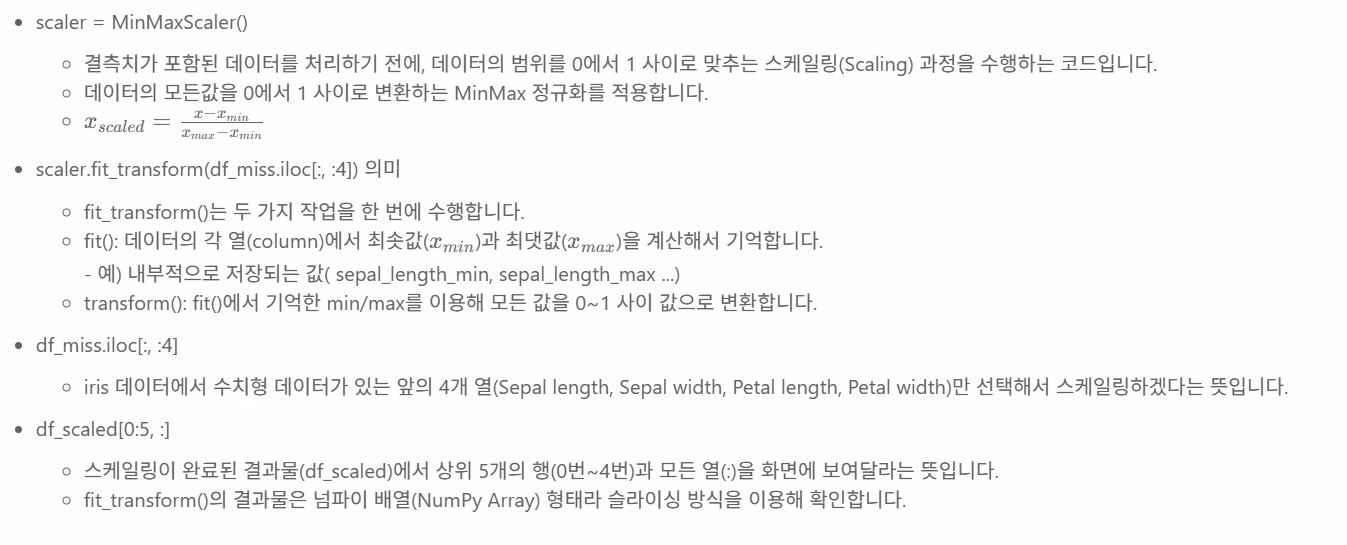


In [ ]:
# (1) 데이터 정규화 (Normalization)
scaler = MinMaxScaler()         # 스케일러 객체 생성 (0 ~ 1 범위)
df_scaled = scaler.fit_transform(df_miss.iloc[:, :4])   # 데이터 학습 및 정규화 변환
print(df_scaled[0:5, :])        # 변환된 결과 상위 5행 출력

[[0.22222222 0.625             nan        nan]
 [0.16666667 0.41666667        nan 0.04166667]
 [0.11111111 0.5        0.05084746        nan]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


---

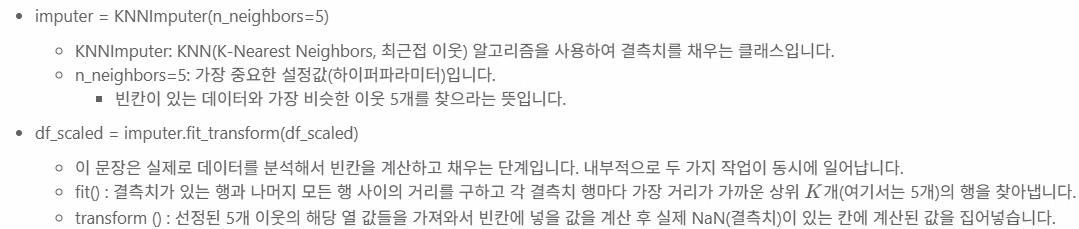

In [ ]:
# (2) 결측치 추정
imputer = KNNImputer(n_neighbors=5)
df_scaled = imputer.fit_transform(df_scaled)    # 결측치 추정
print("--- 결측치 추정 완료 (0~1 스케일 상태)---")
print(df_scaled[0:5, :])

--- 결측치 추정 완료 (0~1 스케일 상태)---
[[0.22222222 0.625      0.0779661  0.09166667]
 [0.16666667 0.41666667 0.08474576 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


In [ ]:
# (3) 정규화 이전으로 변환 
df_filled = scaler.inverse_transform(df_scaled)
print("\n--- 원래 단위로 복구된 데이터 (상위 5행)---")
print(df_filled[0:5, :])


--- 원래 단위로 복구된 데이터 (상위 5행)---
[[5.1  3.5  1.46 0.32]
 [4.9  3.   1.5  0.2 ]
 [4.7  3.2  1.3  0.2 ]
 [4.6  3.1  1.5  0.2 ]
 [5.   3.6  1.4  0.2 ]]


In [ ]:
# 결측치가 있던 df_miss에 계산된 값 채워넣기
df_miss.iloc[:,:4] = df_filled

In [ ]:
# (4) 결과 비교 확인
print("\n---[비교] 결측치가 채워진 데이터(df_miss)---")
print(df_miss.head(4))

print("\n---[비교] 실제 원본 데이터 (df_org)---")
print(df_org.head(4))


---[비교] 결측치가 채워진 데이터(df_miss)---
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5          1.46         0.32  setosa
1           4.9          3.0          1.50         0.20  setosa
2           4.7          3.2          1.30         0.20  setosa
3           4.6          3.1          1.50         0.20  setosa

---[비교] 실제 원본 데이터 (df_org)---
   Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa


---
- Outlier(이상치)란 대부분의 데이터 분포에서 유난히 멀리 떨어져 있는 값을 말합니다.
- 이상치가 생기는 이유

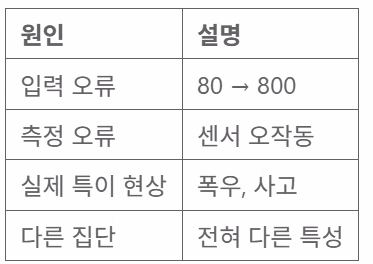

- 대표적인 이상치 판별법
    1. IQR 방법
        - Q1: 1사분위수,Q3: 3사분위수, IQR = Q3 - Q1
        - Lower Bound = Q1-1.5xIQR
        - Upper BOund = Q3+1.5xIQR
        - Lower Bound 보다 작거나 UpperBound 보다 크면 이상치
    2. Z-score 방법
        - 데이터 값들이 편균으로부터 표준편차에 비해 얼마나 떨어져 있는지를 나타낸 것입니다.

        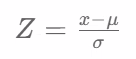

        - 예)

        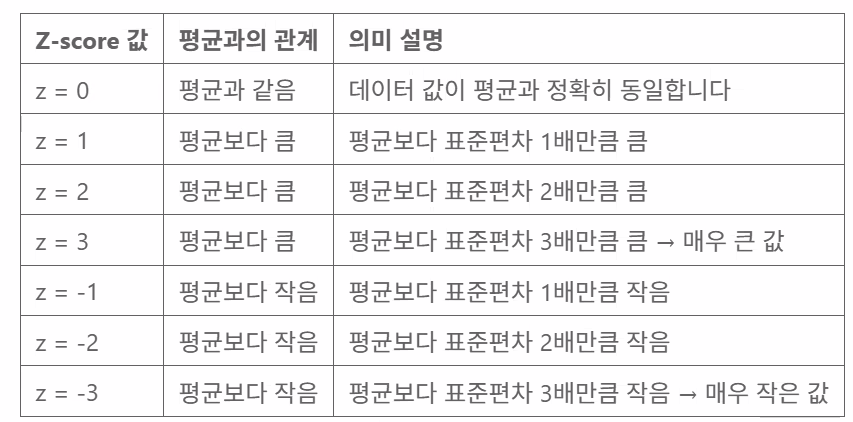

        - |z|값이 클수록 평균에서 멀리 떨어진 값이며, 이상치일 가능성이 커집니다.


In [ ]:
import pandas as pd
import numpy as np
from scipy import stats # scipy 라이브러리의 stats(통계) 모듈을 가져옵니다.
                        # scipy: 과학(science) + 파이썬(python)의 합성어

df = pd.read_csv('../data/iris.csv')  # 판다스 DataFrame df 로 저장
sw = df.Sepal_Width # 꽃 받침 너비  # sw는 Sepal_Width 열 하나만 뽑은 Series 객체

# Z-score 이용
z = np.abs(stats.zscore(sw))    # |Z| > 2 -> 이상치로 판단하겠습니다.
outliers = sw[z > 2]            # 이상치의 기준이 되는 2를 임계값(threshold)이라고 합니다.
print(outliers)                 # 총 5개의 이상치

14    4.0
15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64


In [ ]:
# IQR 이용
Q1 = sw.quantile(0.25)
Q3 = sw.quantile(0.75)
IQR = Q3 - Q1

outliers = sw[(sw < Q1 - IQR*1.5) | (sw >Q3 + IQR*1.5)]
print(outliers) # 총 4개의 이상치

15    4.4
32    4.1
33    4.2
60    2.0
Name: Sepal_Width, dtype: float64


---
## 이상치 탐지 및 탐색적 데이터 분석 (EDA)
데이터 분석과 모델링에 앞서 데이터의 특성을 파악하고 정제하는 과정은 분석 결과의 신뢰도를 결정하는 핵심 단계입니다.
    1. 이상치 탐지
        - Z-score vs IQR
        - 이상치는 정의하는 기준에 따라 결과가 달라지므로, 데이터의 분포와 분석 목적에 맞춰 선택해야 합니다.
    2. 주요 특징 비교
    
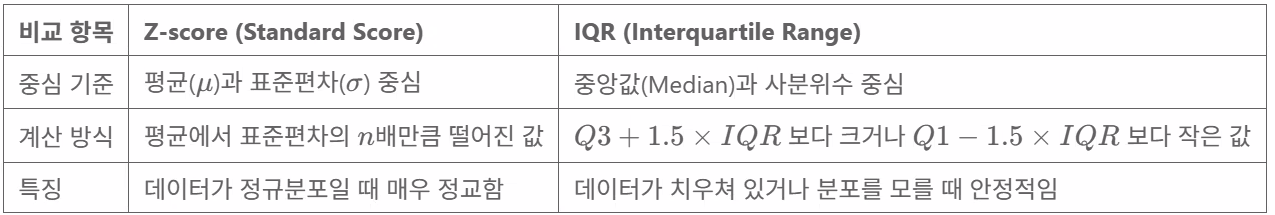

    3. 상황별 선택
        - Z-score: 데이터가 정규분포를 만족할 때, 통계적 엄격함이 필요할 때.
        - IQR: 분포를 모르거나 왜곡(Skewed)되었을 때, EDA단계에서 시각적으로 확인할 때
        - 머신러닝: 두 방식을 모두 비교하여 모델 성능(Accuracy 등)이 더 좋은 기준을 채택.

---
정렬

In [ ]:
df = pd.read_csv('../data/iris.csv')

# 데이터프레임의 정렬
# 오름차순 정렬
df_sorted = df.sort_values('Sepal_Length')
print(df_sorted.head(10))
# 원래의 데이터 프레임에서의 행번호(인덱스)를 유지합니다.

    Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
13           4.3          3.0           1.1          0.1  setosa
8            4.4          2.9           1.4          0.2  setosa
42           4.4          3.2           1.3          0.2  setosa
38           4.4          3.0           1.3          0.2  setosa
41           4.5          2.3           1.3          0.3  setosa
22           4.6          3.6           1.0          0.2  setosa
3            4.6          3.1           1.5          0.2  setosa
6            4.6          3.4           1.4          0.3  setosa
47           4.6          3.2           1.4          0.2  setosa
2            4.7          3.2           1.3          0.2  setosa


In [ ]:
# (1) 데이터 정규화 (Normalization)
scaler = MinMaxScaler()         # 스케일러 객체 생성 (0 ~ 1 범위)
df_scaled = scaler.fit_transform(df_miss.iloc[:, :4])   # 데이터 학습 및 정규화 변환
print(df_scaled[0:5, :])        # 변환된 결과 상위 5행 출력

[[0.22222222 0.625      0.0779661  0.09166667]
 [0.16666667 0.41666667 0.08474576 0.04166667]
 [0.11111111 0.5        0.05084746 0.04166667]
 [0.08333333 0.45833333 0.08474576 0.04166667]
 [0.19444444 0.66666667 0.06779661 0.04166667]]


In [ ]:
# 내림차순 정렬
df_sorted = df.sort_values('Sepal_Length', ascending=False)
df_sorted.head(10)

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species
131,7.9,3.8,6.4,2.0,virginica
122,7.7,2.8,6.7,2.0,virginica
118,7.7,2.6,6.9,2.3,virginica
117,7.7,3.8,6.7,2.2,virginica
135,7.7,3.0,6.1,2.3,virginica
105,7.6,3.0,6.6,2.1,virginica
130,7.4,2.8,6.1,1.9,virginica
107,7.3,2.9,6.3,1.8,virginica
109,7.2,3.6,6.1,2.5,virginica
129,7.2,3.0,5.8,1.6,virginica


In [ ]:
# 여러 개의 기준 컬럼 적용
# 'Species'를 기준으로 오름차순으로 정렬합니다.
# 만약 Species 컬럼의 값이 동일한 행들이 있으면 ' Sepal Width'를 기준으로 오름차순 정렬합니다.
df_sorted = df.sort_values(['Species', 'Sepal_Width'])
print(df_sorted.head(10))

    Sepal_Length  Sepal_Width  Petal_Length  Petal_Width Species
41           4.5          2.3           1.3          0.3  setosa
8            4.4          2.9           1.4          0.2  setosa
1            4.9          3.0           1.4          0.2  setosa
12           4.8          3.0           1.4          0.1  setosa
13           4.3          3.0           1.1          0.1  setosa
25           5.0          3.0           1.6          0.2  setosa
38           4.4          3.0           1.3          0.2  setosa
45           4.8          3.0           1.4          0.3  setosa
3            4.6          3.1           1.5          0.2  setosa
9            4.9          3.1           1.5          0.1  setosa


---
ranking(순위)
- 순위 산정 방식 옵션\
    method='average'(기본)


In [ ]:
import pandas as pd

# 중복값이 포함된 간단한 데이터 생성 (20이 두 번 반복됨)
data = {'Score': [10, 20, 20, 30]}
df_test = pd.DataFrame(data)

# 각 옵션별로 순위 계산
# rank()는 기본적으로 값이 가장 작은 데이터가 1위가 됩니다.(오름차순)
df_test['average'] = df_test['Score'].rank(method='average')    # 기본값, 공동순위의 평균값을 부여
df_test['min'] = df_test['Score'].rank(method='min')            # 공동 순위 중 가장 낮은(작은) 순위 부여
df_test['max'] = df_test['Score'].rank(method='max')            # 공동 순위 중 가장 높은(큰) 순위 부여
df_test['first'] = df_test['Score'].rank(method='first')        # 데이터에 나타나는 순서데로 차등을 부여
df_test['dense'] = df_test['Score'].rank(method='dense')       # 'min'과 같지만, 다음 순위가 바로 이어짐

print(df_test)
# 순위를 보면 소수점이 보입니다. method='average'인 경우 값이 같을 경우 그 데이터들이 차지해야 할 순위들의 평균값을 계산합니다.
# 10: 전체에서 1등입니다. -> 1.0
# 20: 2등과 3등 자리를 차지해야 합니다.
# 평균 계산: (2 + 3) / 2 = 2.5
# 2.5라는 순위를 갖습니다.

   Score  average  min  max  first  dense
0     10      1.0  1.0  1.0    1.0    1.0
1     20      2.5  2.0  3.0    2.0    2.0
2     20      2.5  2.0  3.0    3.0    2.0
3     30      4.0  4.0  4.0    4.0    3.0


---
iris.csv를 이용한 예제

In [ ]:
df = pd.read_csv('../data/iris.csv')

# 기본값 (Ascending): 기본적으로 값이 가장 작은 데이터가 1위가 됩니다. (오름차순)
print(df['Petal_Length'].rank().head())
# 'Petal_Length'의 순위
# 0     18.0 의미는 인덱스 순위가 18번째로 작다는 의미입니다.
# 그런데 rank()결과가 float64(실수)로 표현되고 있습니다.

0    18.0
1    18.0
2     8.0
3    31.0
4    18.0
Name: Petal_Length, dtype: float64


In [ ]:
# astype(int) : 정수형 변환
print(df['Petal_Length'].rank().astype(int))

0       18
1       18
2        8
3       31
4       18
      ... 
145    117
146    106
147    117
148    121
149    112
Name: Petal_Length, Length: 150, dtype: int64


In [ ]:
print(df['Petal_Length'].rank(ascending= False).astype(int))    # 내림차순 순위

0      133
1      133
2      143
3      120
4      133
      ... 
145     33
146     44
147     33
148     29
149     38
Name: Petal_Length, Length: 150, dtype: int64


---
데이터 샘플링(Data Sampling)이란 전체 데이터(모집단)를 분석하기 어려울때, 그중 일부인 표본(Sample)을 추출하여 전체의 특성을 추론하는 통계적 기법입니다.

1. random Sampling

In [ ]:
import pandas as pd
import itertools

df = pd.read_csv('../data/iris.csv')

# df.sample(...)는 DataFrame에서 무작위(ramdom)로 행을 추출합니다.
# DataFrame df에서 임의로 20개 행을 추출하여 df20에 저장합니다.
# 단, random_state를 고정해 항상 같은 20개가 선택되도록 합니다.(실행할 때 마다 항상 같은 표본이 선택됩니다.)
df20 = df.sample(n=20, random_state=123) # random_state가 없으면 실행할 때마다 다른 결과가 나옵니다.
print(df20)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width     Species
72            6.3          2.5           4.9          1.5  versicolor
112           6.8          3.0           5.5          2.1   virginica
132           6.4          2.8           5.6          2.2   virginica
88            5.6          3.0           4.1          1.3  versicolor
37            4.9          3.6           1.4          0.1      setosa
138           6.0          3.0           4.8          1.8   virginica
87            6.3          2.3           4.4          1.3  versicolor
42            4.4          3.2           1.3          0.2      setosa
8             4.4          2.9           1.4          0.2      setosa
90            5.5          2.6           4.4          1.2  versicolor
141           6.9          3.1           5.1          2.3   virginica
33            5.5          4.2           1.4          0.2      setosa
59            5.2          2.7           3.9          1.4  versicolor
116           6.5   

---
2. 층화 샘플링(Stratified Sampling) 전체 데이터를 서로 중복되지 않는 여러 개의 하위 집단(층, Strata)으로 나눈 뒤, 집단 내에서 독립적으로 무작위 추출을 수행하는 방법입니다.


In [ ]:
# 'Samecies'기준으로 그룹화 합니다.
groups = df.groupby('Species')
print(groups)

In [ ]:
# roups.head()를 실행하면 각 그룹(Species)별로 상위 5행씩을 추출하여 보여줍니다.
print(groups.head())

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width     Species
0             5.1          3.5           1.4          0.2      setosa
1             4.9          3.0           1.4          0.2      setosa
2             4.7          3.2           1.3          0.2      setosa
3             4.6          3.1           1.5          0.2      setosa
4             5.0          3.6           1.4          0.2      setosa
50            7.0          3.2           4.7          1.4  versicolor
51            6.4          3.2           4.5          1.5  versicolor
52            6.9          3.1           4.9          1.5  versicolor
53            5.5          2.3           4.0          1.3  versicolor
54            6.5          2.8           4.6          1.5  versicolor
100           6.3          3.3           6.0          2.5   virginica
101           5.8          2.7           5.1          1.9   virginica
102           7.1          3.0           5.9          2.1   virginica
103           6.3   

In [ ]:
# 층화 샘플링(stratified sampling)
# Species 별로 데이터를 나눈 뒤, 각 그룹에서 20%씩 무작위로 추출하여 비율을 유지한 표본을 만듭니다.
# x.sample(frac=0.2, random_state=123): 각 품종 그룹에서 20% 비율로 무작위 추출합니다. (각 품종의 그룹의 수 50개 0.2 10개)
stratified = df.groupby('Species').sample(frac=0.2, random_state=123)
print(stratified)

     Sepal_Length  Sepal_Width  Petal_Length  Petal_Width     Species
10            5.4          3.7           1.5          0.2      setosa
13            4.3          3.0           1.1          0.1      setosa
30            4.8          3.1           1.6          0.2      setosa
46            5.1          3.8           1.6          0.2      setosa
18            5.7          3.8           1.7          0.3      setosa
0             5.1          3.5           1.4          0.2      setosa
40            5.0          3.5           1.3          0.3      setosa
12            4.8          3.0           1.4          0.1      setosa
29            4.7          3.2           1.6          0.2      setosa
8             4.4          2.9           1.4          0.2      setosa
54            6.5          2.8           4.6          1.5  versicolor
55            5.7          2.8           4.5          1.3  versicolor
50            7.0          3.2           4.7          1.4  versicolor
87            6.3   

---
combinations(조합)
    - combinations는 여러 개 중에서 중복은 없고 순서와 상관없이 정해진 개수만큼 뽑는 모든 경우의 수(조합)를 만듭니다.

In [ ]:
# Species 열에 존재하는 고유한 값만 추출
species = df.Species.unique()
print(species)  # numpy 배열 리턴

<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str


In [ ]:
# itertools.combination(species, 2)는 species에서 순서 없이 2개씩 뽑는 조합(combination) 생성합니다.
comb = list(itertools.combinations(species, 2))
print(comb)

[('setosa', 'versicolor'), ('setosa', 'virginica'), ('versicolor', 'virginica')]


---
데이터 집계(aggregation)은 데이터프레임과 같은 2차원 데이터에서 데이처 그룹에 대한 합계나 평균을 계산하는 작업입니다.
- 집계를 수행하려면 groupby() 메서드를 이용합니다.

In [ ]:
df = pd.read_csv('../data/iris.csv')

# 품종별 평균
df_agg = df.groupby('Species').mean()
print(df_agg)

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa             5.006        3.428         1.462        0.246
versicolor         5.936        2.770         4.260        1.326
virginica          6.588        2.974         5.552        2.026


In [ ]:
# 품종별 표준편차
df_agg = df.groupby('Species').std()
print(df_agg)

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa          0.352490     0.379064      0.173664     0.105386
versicolor      0.516171     0.313798      0.469911     0.197753
virginica       0.635880     0.322497      0.551895     0.274650


In [ ]:
# 품종별 최대값
df_agg = df.groupby('Species').max()
print(df_agg)

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa               5.8          4.4           1.9          0.6
versicolor           7.0          3.4           5.1          1.8
virginica            7.9          3.8           6.9          2.5


In [ ]:
# 품종별 최소값
df_agg = df.groupby('Species').min()
print(df_agg)

            Sepal_Length  Sepal_Width  Petal_Length  Petal_Width
Species                                                         
setosa               4.3          2.3           1.0          0.1
versicolor           4.9          2.0           3.0          1.0
virginica            4.9          2.2           4.5          1.4


In [ ]:
# 컬럼마다 맞춤형 통계 적용
# df.groupby('Species'): 전체 데이터를 'Species(품종)' 컬럼의 값(setosa, versicolor, Virginica)에 따라 3개의 그룹으로 나눕니다.
# agg({...}): agg는 Aggregation(집계)의 약자로, 여러 개의 통계 함수를 딕셔너리({키 : 값}) 형태로 한꺼번에 적용하겠다는 뜻입니다.
df_custom = df.groupby('Species').agg({
    'Sepal_Length': 'mean',           # 'Species_Length':'mean'   -> 꽃받침 길이의 평균
    'Petal_Width': 'max',             # 'Petal_Width': 'max'    -> 꽃잎 너비중 가장 큰 값
    'Sepal_Width': 'count'            # 'Sepal_Width': 'count'  -> 꽃받침 너비 개수
})
print(df_custom)

            Sepal_Length  Petal_Width  Sepal_Width
Species                                           
setosa             5.006          0.6           50
versicolor         5.936          1.8           50
virginica          6.588          2.5           50


In [ ]:
# 품종별로 꽃잎 길이(Petal_Length)의 범위(최댓값 - 최솟값)를 계산
df_range = df.groupby('Species')['Petal_Length'].apply(lambda x: x.max() - x.min())
print(df_range)

Species
setosa        0.9
versicolor    2.1
virginica     2.4
Name: Petal_Length, dtype: float64


---
그룹핑 그룹이 두 개인 경우

In [ ]:
# 데이터프레임의 컬럼(열)이 너무 많을 때, 판다스가 이를 여러 줄로 나누어 표시할지 여부를 결정합니다.
# 설정값 (False): 화면 너비를 넘어가더라도 줄바꿈을 하지 않고 한 줄에 길게 보여줍니다. (중간에 ...으로 생략됨)
pd.set_option('display.expand_frame_repr', False)

In [ ]:
df = pd.read_csv('../data/mtcars.csv')
print(df[df['cyl'] == 4])   # cyl 값이 4인 행만 출력합니다.

             model   mpg  cyl   disp   hp  drat     wt   qsec  vs  am  gear  carb
2       Datsun 710  22.8    4  108.0   93  3.85  2.320  18.61   1   1     4     1
7        Merc 240D  24.4    4  146.7   62  3.69  3.190  20.00   1   0     4     2
8         Merc 230  22.8    4  140.8   95  3.92  3.150  22.90   1   0     4     2
17        Fiat 128  32.4    4   78.7   66  4.08  2.200  19.47   1   1     4     1
18     Honda Civic  30.4    4   75.7   52  4.93  1.615  18.52   1   1     4     2
19  Toyota Corolla  33.9    4   71.1   65  4.22  1.835  19.90   1   1     4     1
20   Toyota Corona  21.5    4  120.1   97  3.70  2.465  20.01   1   0     3     1
25       Fiat X1-9  27.3    4   79.0   66  4.08  1.935  18.90   1   1     4     1
26   Porsche 914-2  26.0    4  120.3   91  4.43  2.140  16.70   0   1     5     2
27    Lotus Europa  30.4    4   95.1  113  3.77  1.513  16.90   1   1     5     2
31      Volvo 142E  21.4    4  121.0  109  4.11  2.780  18.60   1   1     4     2


In [ ]:
# cyl : 실린더 수, vs : 엔진 형태 (0=V형, 1=직렬)
df_agg = df.groupby(['cyl','vs']).max()
print()

---
데이터 병합(merge)은 흩어진 데이터를 하나로 모으는 작업을 의미합니다.

In [ ]:
df1 = pd.DataFrame([[169, 58, 1.0],
                    [172, 73, 1.2],
                    [184, 82, 0.7]],
                columns=['height', 'weight', 'eye'])
df2 = pd.DataFrame([[176, 71, 0.8, 'M'],
                    [169, 62, 0.7, 'F'],
                    [158, 60, 1.3, 'M']],
                columns=['height', 'weight', 'eye', 'gender'])
df3 = pd.DataFrame([[3, 22],
                    [2, 21]],
                columns=['grade', 'age'])

In [ ]:
print(df1)

   height  weight  eye
0     169      58  1.0
1     172      73  1.2
2     184      82  0.7


In [ ]:
print(df2)

   height  weight  eye gender
0     176      71  0.8      M
1     169      62  0.7      F
2     158      60  1.3      M


In [ ]:
print(df3)

   grade  age
0      3   22
1      2   21


In [ ]:
df12 = pd.concat([df1, df2])    # 행, 방향 병합
print(df12)
# df1에 gender 컬럼이 없어 NaN으로 표시됩니다.
# 병합된 데이터프레임의 인덱스가 병합 전 데이터 프레임의 번호 그래오 유지되고 있어 다시 초기화 해야 합니다.

   height  weight  eye gender
0     169      58  1.0    NaN
1     172      73  1.2    NaN
2     184      82  0.7    NaN
0     176      71  0.8      M
1     169      62  0.7      F
2     158      60  1.3      M


In [ ]:
# drop=True: 기존의 인덱스를 완전히 삭제라고, 0부터 시작하는 새로운 인덱스만 남깁니다.
df12 = df12.reset_index(drop=True)  # 인덱스 재설정
print(df12)

   height  weight  eye gender
0     169      58  1.0    NaN
1     172      73  1.2    NaN
2     184      82  0.7    NaN
3     176      71  0.8      M
4     169      62  0.7      F
5     158      60  1.3      M


In [ ]:
df13 = pd.concat([df1, df3], axis=1)    # 열 방향 병합
print(df13)

   height  weight  eye  grade   age
0     169      58  1.0    3.0  22.0
1     172      73  1.2    2.0  21.0
2     184      82  0.7    NaN   NaN


In [ ]:
df12 = pd.concat([df1, df2], axis=1)    # 열 방향 병합
print(df12)

   height  weight  eye  height  weight  eye gender
0     169      58  1.0     176      71  0.8      M
1     172      73  1.2     169      62  0.7      F
2     184      82  0.7     158      60  1.3      M


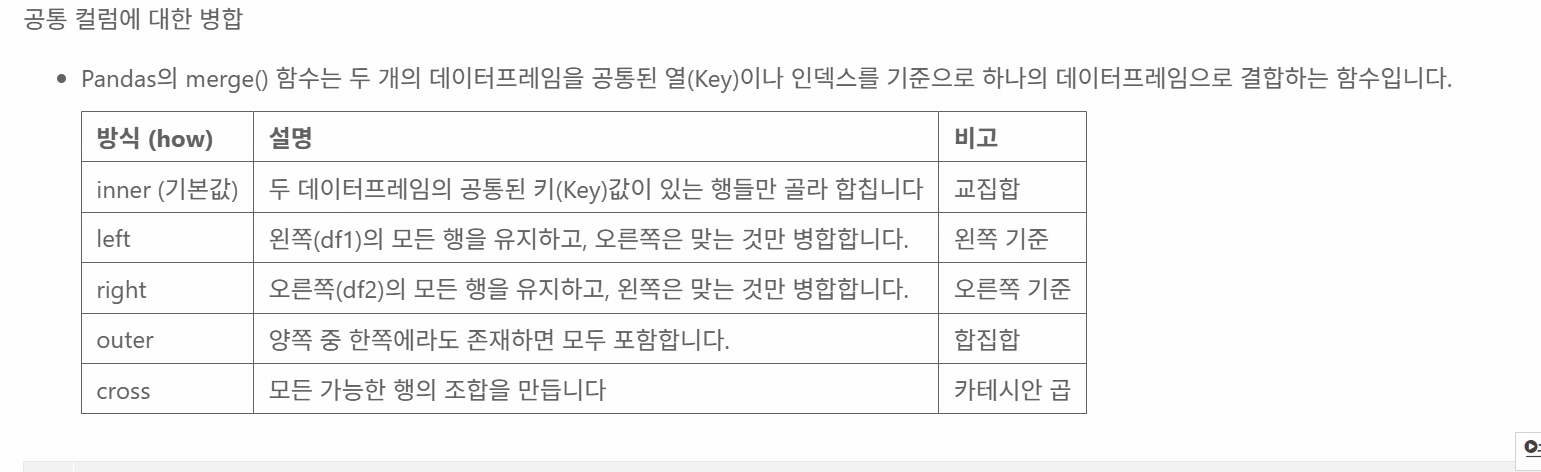

In [ ]:
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name', 'math'])

In [ ]:
print(df1)

  name  kor
0    a   90
1    b   80
2    c   40


In [ ]:
print(df2)

  name  math
0    a    75
1    b    60
2    d    90


In [ ]:
# 교차 결합(Cross Join)은 df1의 모든 행과 df2의 모든 행을 하나하나 빠집없이 다 조합합니다.
# 두 데이터의 프레임의 행이 각각3개씩 이므로, 결과는 총 3 x 3 = 9개의 행이 생성되었습니다.

# 컬럼명 자동 변경: df1과 df2에 동일한 이름의 컬럼(name)이 있기 때문에
# 이를 구분하기 위해 자동으로 _X(왼쪽 df), _y(오른쪽 df) 접미사가 붙습니다.

print(df1.merge(df2, how='cross'))

  name_x  kor name_y  math
0      a   90      a    75
1      a   90      b    60
2      a   90      d    90
3      b   80      a    75
4      b   80      b    60
5      b   80      d    90
6      c   40      a    75
7      c   40      b    60
8      c   40      d    90


In [ ]:
# on='name'는 df1과 df2의 공돝 컬럼name을 의미합니다, 반드시 on에서는 공통컬럼을 지정합니다.
df12 = df1.merge(df2, on=['name'])      
print(df12)

  name  kor  math
0    a   90    75
1    b   80    60


In [ ]:
print(df12.info())

<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   name    2 non-null      str  
 1   kor     2 non-null      int64
 2   math    2 non-null      int64
dtypes: int64(2), str(1)
memory usage: 180.0 bytes
None


In [ ]:
df12 = df1.merge(df2, how='left', on='name')    # left
print(df12)

  name  kor  math
0    a   90  75.0
1    b   80  60.0
2    c   40   NaN


In [ ]:
print(df2['math'].dtype)    # int64
print(df12['math'].dtype)   # float64

# 정수형 (int64) 컬럼은 NaN을 표현할 수 없기 때문에
# NaN이 포함되면 Pandas가 자동으로 float64 타입으로 변환합니다.
print(df12.info())

int64
float64
<class 'pandas.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   name    3 non-null      str    
 1   kor     3 non-null      int64  
 2   math    2 non-null      float64
dtypes: float64(1), int64(1), str(1)
memory usage: 204.0 bytes
None


In [ ]:
df12 = df1.merge(df2, how='right', on='name')    # rigth
print(df12)

  name   kor  math
0    a  90.0    75
1    b  80.0    60
2    d   NaN    90


In [ ]:
df12 = df1.merge(df2, how='outer', on= 'name')    #out
print(df12)

  name   kor  math
0    a  90.0  75.0
1    b  80.0  60.0
2    c  40.0   NaN
3    d   NaN  90.0


---
공통 컬럼으로 사용할 컬럼이 다른 경우

In [ ]:
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                   columns=['name1', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                   columns=['name2', 'math'])

In [ ]:
# df1에서 'name1'의 값(예: 'a')과 df2에서 'name2'의 값(예: 'a')를 찾아 두 행을 가로로 결합합니다.
# 병합 후 결과물에서는 'name1' 과 'name2' 컬럼이 둘 다 나타납니다. 내용은 같이지만 이름이 다르기 때문입니다.
# 별도의 how 옵션이 없으므로 기본값인 inner(교집합) 방식으로 동작합니다.
df12 = df1.merge(df2, left_on='name1', right_on='name2')
print(df12)

  name1  kor name2  math
0     a   90     a    75
1     b   80     b    60


In [ ]:
df12 = df1.merge(df2, how='left', left_on='name1', right_on='name2')
print(df12)

  name1  kor name2  math
0     a   90     a  75.0
1     b   80     b  60.0
2     c   40   NaN   NaN


In [ ]:
df12 = df1.merge(df2, how='right', left_on='name1', right_on='name2')
print(df12)

  name1   kor name2  math
0     a  90.0     a    75
1     b  80.0     b    60
2   NaN   NaN     d    90


In [ ]:
df12 = df1.merge(df2,how='outer', left_on='name1', right_on='name2')
print(df12)

  name1   kor name2  math
0     a  90.0     a  75.0
1     b  80.0     b  60.0
2     c  40.0   NaN   NaN
3   NaN   NaN     d  90.0


---
join(): 인덱스(index)를 기준으로 두 DataFrame을 결합하는 메서드
- 컬럼명이 달라도 index만 같으면 join 가능

In [ ]:
df1 = pd.DataFrame([['a', 90], ['b', 80], ['c', 40]],
                    columns=['name1', 'kor'])
df2 = pd.DataFrame([['a', 75], ['b', 60], ['d', 90]],
                    columns=['name2', 'math'])

In [ ]:
print(df1)

  name1  kor
0     a   90
1     b   80
2     c   40


In [ ]:
# 'name1'을 index로 설정
df1_i = df1.set_index('name1')
print(df1_i)
# 아래 출력결과를 보면 첫 줄은 컬럼 이름이 나옵니다.
# name1: 인덱스의 이름입니다. kor보다 한 단계 아래 줄에 위치하며 안쪽에 치우쳐 있습니다.
# 이렇게 엇갈리게 배치되는 이유는 판다스가 이것은 데이터 값(Value)이 아니라 행을 구분하는 제목(index)이다라는 것을
# 사용자에게 알려주기 위한 약속된 디자인 입니다.

       kor
name1     
a       90
b       80
c       40


In [ ]:
df2_i = df2.set_index('name2')
print(df2_i)

       math
name2      
a        75
b        60
d        90


In [ ]:
# join 실행 (left join)
# join은 기본적으로 왼쪽 데이터프레임(df1_i)의 인덱스를 유지하고, 오른쪽 데이터(df2_i)에서 인덱스가 같은 것만 가져와 붙입니다.
result = df1_i.join(df2_i)  # how='left'(기본값)
print(result)

       kor  math
name1           
a       90  75.0
b       80  60.0
c       40   NaN


In [ ]:
# 두 데이터프레임의 인덱스(Index)가 겹치는 부분만 골라내어 가로로 합치겠다는 의미입니다.
result = df1_i.join(df2_i, how='inner')
print(result)

       kor  math
name1           
a       90    75
b       80    60


In [ ]:
result = df1_i.join(df2_i, how='outer')
print(result)

        kor  math
name1            
a      90.0  75.0
b      80.0  60.0
c      40.0   NaN
d       NaN  90.0


---
피벗 테이블
- 많은 양의 데이터에서 필요한 자료만 뽑아 새롭게 집계된 표를 작성하는 기능입니다.

In [ ]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import seaborn as sns # 파이썬에서 데이터를 시각화할 때 사용하는 핵심 라이브러리 중 하나입니다.
# 피벗 테이블 작성
df = sns.load_dataset('tips')   # seaborn에서 제공하는 tips 데이터 셋을 불러옵니다.
print(df.shape) # (244, 7)
print(df.head())
# tips 데이터셋은 레스토랑 계산서와 팁(tip)에 관한 예제용 데이터입니다.

(244, 7)
   total_bill   tip     sex smoker  day    time  size
0       16.99  1.01  Female     No  Sun  Dinner     2
1       10.34  1.66    Male     No  Sun  Dinner     3
2       21.01  3.50    Male     No  Sun  Dinner     3
3       23.68  3.31    Male     No  Sun  Dinner     2
4       24.59  3.61  Female     No  Sun  Dinner     4


In [ ]:
# DataFrame을 CSV 파일로 저장하기
# 인덱스 제외하고 저장
df.to_csv('tips.csv', index=False)

# 한글 깨짐 방지
# df.to_csv('tips.csv', index=False, encoding='utf-8-sig')

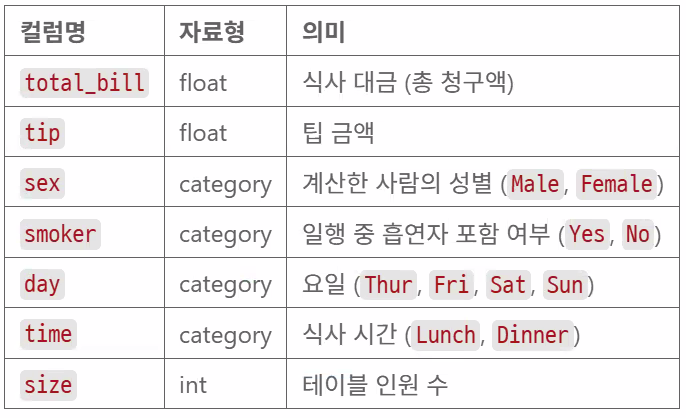

In [ ]:
print(df.dtypes)
# sex           category

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object


In [ ]:
# 범주(category) 값만 확인
print(df['sex'].cat.categories)

Index(['Male', 'Female'], dtype='str')


In [ ]:
# Female 행만 추출
df_Female = df[df['sex'] == 'Female']
print(df_Female.dtypes)

print()
print(df_Female.shape)
print(df_Female['sex'].cat.categories)  # Male은 범주에는 있지만 데이터에는 없습니다.

# Categroy 타입에서 행을 필터링해도 범주(categories)는 자동으로 제거되지 않습니다.
# 이는 데이터 구조의 일관성을 유지하기 위한 Pandas의 설계 철학입니다.

total_bill     float64
tip            float64
sex           category
smoker        category
day           category
time          category
size             int64
dtype: object

(87, 7)
Index(['Male', 'Female'], dtype='str')


---
observed=False와 observed=True 옵션 차이 확인
- 현재 df_Feamle에는 성별이 'Female'인 데이터만 존재합니다.
- 하지만 카테고리에는 Male도 포함되어 있습니다.
- observed 옵션은 '범주는 존재하지만, 실제 데이터(행)는 단 하나도 없는 경우'에만 차이를 만듭니다.
---
집계함수가 count(),sum() 인 경우 데이터가 없으면 0, 0.0 으로 리턴합니다.

In [ ]:
# 성별(sex) 총 계산금액(total_bill) 계산
p1 = df_Female.pivot_table(index= 'sex',    # 행 위치에 들어갈 칼럼
                        values='total_bill', # 데이터로 사용할 컬럼
                        aggfunc='sum',       # 데이터 집계함수
                        observed=False     # 실제로 존재하지 않는 범주 조합도 결과에 포함
                        )
print(p1)

        total_bill
sex               
Male          0.00
Female     1570.95


In [ ]:
# 성별(sex) 총 계산금액(total_bill) 계산
p1 = df_Female.pivot_table(index= 'sex',    # 행 위치에 들어갈 칼럼
                        values='total_bill', # 데이터로 사용할 컬럼
                        aggfunc='sum',       # 데이터 집계함수
                        observed=True     # 실제로 존재하는 범주 조합만 결과에 포함
                        )
print(p1)

        total_bill
sex               
Female     1570.95


---
전체 데이터로 피봇 테이블 만들기
\
데이터가 없는 경우 mean(), min(), max(), std → NaN을 반환

In [ ]:
# 방문시간(time) x 요일(day)별로 총 팁금액(tip)의 최댓값을 계산
p2 = df.pivot_table(index='time',   # 행 위치에 들어갈 컬럼
                    columns='day',  # 열 위치에 들어갈 컬럼
                    values='tip',   # 데이터로 사용할 컬럼
                    aggfunc='max',  # 데이터 집계함수
                    observed=False  # 실제로 존재하지 않는 범주 조합도 결과에 포함
                    )
print(p2)

day     Thur   Fri   Sat  Sun
time                         
Lunch    6.7  3.48   NaN  NaN
Dinner   3.0  4.73  10.0  6.5


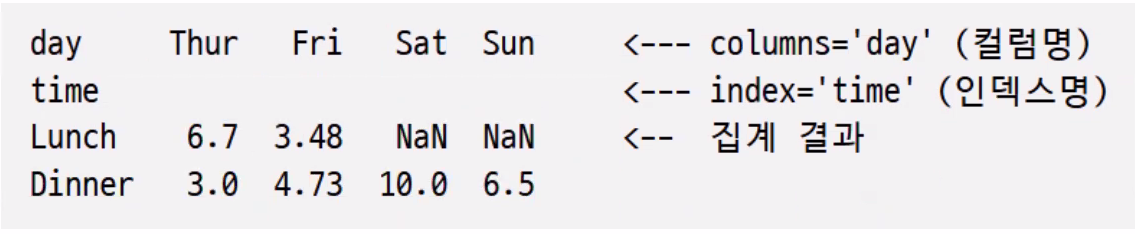

---

In [ ]:
# 방문시간(time) x 요일(day)별로 총 팁금액(tip)의 최솟값을 계산
p3 = df.pivot_table(index='time',   # 행 위치에 들어갈 컬럼
                    columns='day',  # 열 위치에 들어갈 컬럼
                    values='tip',   # 데이터로 사용할 컬럼
                    aggfunc='min',  # 데이터 집계함수
                    observed=False  # 실제로 존재하지 않는 범주 조합도 결과에 포함
                    )
print(p3)

day     Thur   Fri  Sat   Sun
time                         
Lunch   1.25  1.58  NaN   NaN
Dinner  3.00  1.00  1.0  1.01


In [ ]:
# 방문시간(time) x 요일(day)별로 총 팁금액(tip)의 횟수
p4 = df.pivot_table(index='time',   # 행 위치에 들어갈 컬럼
                    columns='day',  # 열 위치에 들어갈 컬럼
                    values='tip',   # 데이터로 사용할 컬럼
                    aggfunc='count',  # 데이터 집계함수
                    observed=False  # 실제로 존재하지 않는 범주 조합도 결과에 포함
                    )
print(p4)

day     Thur  Fri  Sat  Sun
time                       
Lunch     61    7    0    0
Dinner     1   12   87   76


In [ ]:
p5 = df.pivot_table(index='sex',
                    columns='time',
                    values='total_bill',
                    aggfunc='sum',
                    observed=False
                    )
print(p5)

time     Lunch   Dinner
sex                    
Male    595.60  2661.22
Female  571.87   999.08


---
groupby([ ], observed=False)[컬럼명].집계함수() 
1. 집계함수가 count(), sum()인 경우 데이터가 없으면 0,0.0 
2. mean(), min(), max(), std() 데이터가 없으면 NaN

In [ ]:
# df.groupdy(['time', 'day'] : time x day 조합으로 그룹 생성)
# ['tip'] : 각 그룹에서 tip 컬럼만 가져옵니다.
# count() : tip 값이 NaN이 아닌 행의 개수
print(df.groupby(['time', 'day'], observed=True)['tip'].count())

time    day 
Lunch   Thur    61
        Fri      7
Dinner  Thur     1
        Fri     12
        Sat     87
        Sun     76
Name: tip, dtype: int64


In [ ]:
print(df.groupby(['time', 'day'], observed=False)['tip'].count())
# count()는 없는 조합도 0으로 출력

time    day 
Lunch   Thur    61
        Fri      7
        Sat      0
        Sun      0
Dinner  Thur     1
        Fri     12
        Sat     87
        Sun     76
Name: tip, dtype: int64


In [ ]:
print(df.groupby(['time', 'day'], observed=False)['tip'].sum())
# sum()는 없는 조합도 0으로 출력

time    day 
Lunch   Thur    168.83
        Fri      16.68
        Sat       0.00
        Sun       0.00
Dinner  Thur      3.00
        Fri      35.28
        Sat     260.40
        Sun     247.39
Name: tip, dtype: float64


In [ ]:
print(df.groupby(['time', 'day'], observed=False)['tip'].mean())
# mean()의 경우 데이터가 없는 조합은 NaN으로 나옵니다.

time    day 
Lunch   Thur    2.767705
        Fri     2.382857
        Sat          NaN
        Sun          NaN
Dinner  Thur    3.000000
        Fri     2.940000
        Sat     2.993103
        Sun     3.255132
Name: tip, dtype: float64
